# Classifying a non-linear dataset: A MerLin introduction from installation to classification

This notebook will guide you to classify the non-linear moons dataset starting from the installation of ``MerLin``.

Lets first install MerLin with the following cell.

In [ ]:
%pip install merlinquantum

## 1. Imports

Lets first import some packages, especially the ``merlin`` package

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import merlin
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch

## 2. Generate the dataset

We will use sklearn's moons dataset. It is a 2 feature, 2 class non-linear dataset. We will plot the dataset.

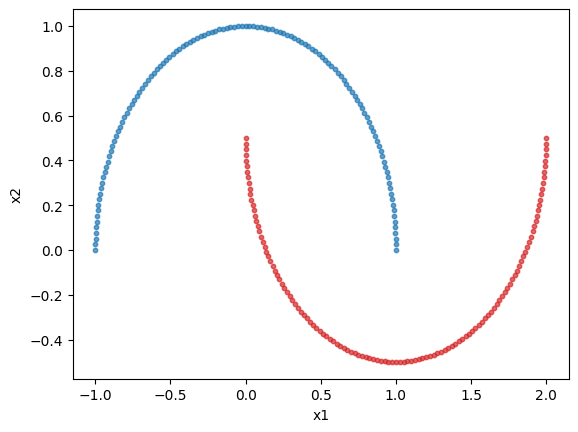

In [44]:
dataset = make_moons(n_samples=250)
X = dataset[0]
y = dataset[1]

# Plotting the dataset
class_1 = []
class_2 = []

for features, label in zip(X, y, strict=True):
    if label == 0:
        class_1.append(features)
    else:
        class_2.append(features)

class_1 = np.array(class_1)
class_2 = np.array(class_2)

plt.scatter(class_1[:, 0], class_1[:, 1], s=10, color="tab:blue", alpha=0.7)
plt.scatter(class_2[:, 0], class_2[:, 1], s=10, color="tab:red", alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 3. Prepare the dataset

We will format the data to have it as tensors and split the dataset into a train and test set.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")


Train size: 187 samples
Test size: 63 samples


## 4. Create a simple MerLin quantum layer

It is now time to use MerLin. We will use a quantum layer to do the classification of the previous dataset. The simplest way to do so is to use the ``QuantumLayer``'s simple method. The input size is the number of features.

In [46]:
layer = merlin.QuantumLayer.simple(input_size=2)

## 5. Training the layer

Since MerLin plugs into pytorch (a ``QuantumLayer`` is a ``torch.nn.Module``), the training of the quantum model is the same as a regular pytorch module. Here is how to implement a simple training loop.

We will use the Adam optimizer, the cross-entropy loss function, a learning rate of 0.05 and 75 epochs.

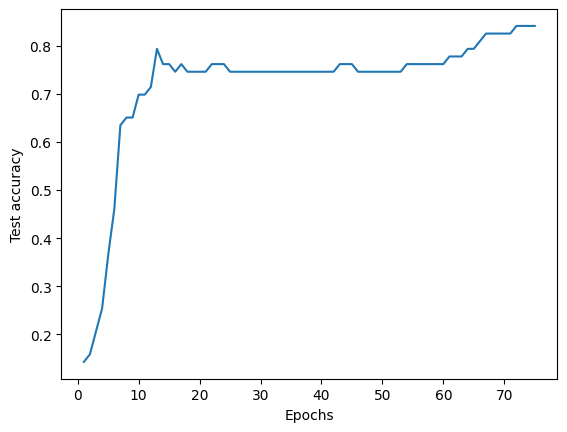

In [48]:
epochs=75
lr=0.05
optimizer = torch.optim.Adam(layer.parameters(), lr=lr)
test_accuracies = []
for _ in range(epochs):
    #Train the model
    layer.train()
    optimizer.zero_grad()
    logits = layer(X_train)
    loss = torch.nn.functional.cross_entropy(logits, y_train)
    loss.backward()
    optimizer.step()

    # Evaluate the accuracy of the model
    layer.eval()
    test_preds = layer(X_test).argmax(dim=1)
    test_acc = (test_preds == y_test).float().mean().item()
    test_accuracies.append(test_acc)


#Plot the accuracy
plt.plot([i for i in range(1,epochs+1)],test_accuracies)
plt.xlabel("Epochs")
plt.ylabel("Test accuracy")
plt.show()

## 6. Evaluate the model

Lets check the performance of the model just a like a regular pytorch module.

In [49]:
layer.eval()
with torch.no_grad():
    train_preds = layer(X_train).argmax(dim=1)
    test_preds = layer(X_test).argmax(dim=1)
    train_acc = (train_preds == y_train).float().mean().item()
    test_acc = (test_preds == y_test).float().mean().item()

print(f"The accuracy of the model on the training set is {train_acc}")
print(f"The accuracy of the model on the test set is {test_acc}")

The accuracy of the model on the training set is 0.7326202988624573
The accuracy of the model on the test set is 0.841269850730896


## 7. Visualize the classification results (decision boundary)

To better visualize the performance of our quantum model, lets plot the decision boundary.

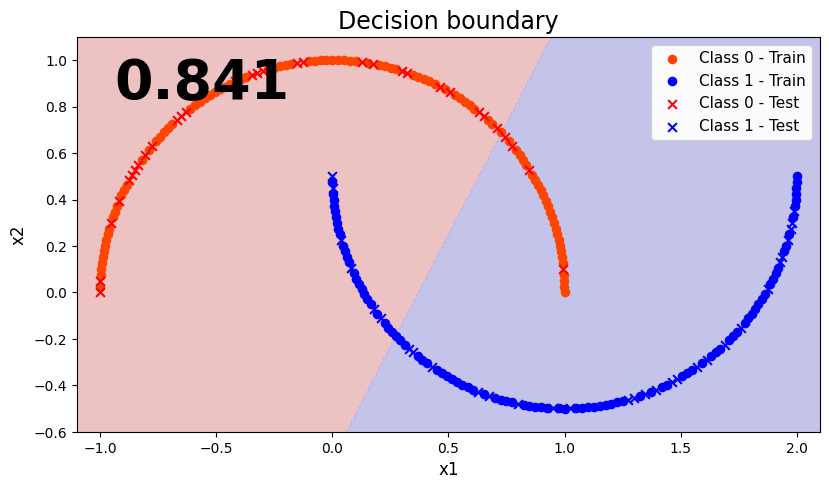

In [50]:
# Plot range from full dataset
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

# Grid
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Predict on grid
layer.eval()
with torch.no_grad():
    out = layer(grid_tensor)
    Z = torch.argmax(out, dim=1)

Z = Z.cpu().numpy().reshape(xx.shape)

# Convert tensors once
X_train_np = X_train.detach().cpu().numpy()
X_test_np = X_test.detach().cpu().numpy()

# Background
bg_cmap = ListedColormap(["#e8b3b3", "#b6b6e6"])
plt.figure(figsize=(8.4, 6.0))
plt.contourf(xx, yy, Z, levels=np.arange(-0.5, 2, 1), cmap=bg_cmap, alpha=0.8)

# Train points
plt.scatter(
    X_train_np[y_train == 0, 0], X_train_np[y_train == 0, 1],
    c="orangered", s=35, marker="o", label="Class 0 - Train"
)
plt.scatter(
    X_train_np[y_train == 1, 0], X_train_np[y_train == 1, 1],
    c="blue", s=35, marker="o", label="Class 1 - Train"
)

# Test points
plt.scatter(
    X_test_np[y_test == 0, 0], X_test_np[y_test == 0, 1],
    c="red", s=40, marker="x", linewidths=1.5, label="Class 0 - Test"
)
plt.scatter(
    X_test_np[y_test == 1, 0], X_test_np[y_test == 1, 1],
    c="blue", s=40, marker="x", linewidths=1.5, label="Class 1 - Test"
)

# Accuracy text
plt.text(
    0.05, 0.95, f"{test_acc:.3f}",
    transform=plt.gca().transAxes,
    fontsize=40, fontweight="bold",
    ha="left", va="top", color="black"
)

plt.title("Decision boundary", fontsize=17)
plt.xlabel("x1", fontsize=12)
plt.ylabel("x2", fontsize=12)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right", fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()